# Real SoftMax Pro plates: outlier QC vs the analyst, and kit-lot normalization

**Data.** Five sandwich-ELISA plates exported from SoftMax Pro. They ship as example data in the
R package **ELISAtools** 0.1.8 (Feng Feng, MIT license; see Feng *et al.*, bioRxiv
[10.1101/483800](https://doi.org/10.1101/483800)). The plates come in two **kit-lot batches**:
three plates in Batch 1 and two in Batch 2. Each plate has 8 standards in triplicate
(3000 → 46.9 pg/mL plus a zero), 15 unknowns in triplicate at 1:10, and the **same QC control**
in triplicate. The analyte is not disclosed. The raw files are in `data/raw/elisatools_feng2019/`.

This dataset has no biology to interpret. It is useful for two engineering questions that come
up on every real ELISA project:

1. The original analyst **masked** wells by hand in SoftMax. How does the pipeline's rule-based
   outlier QC compare?
2. Does a **kit-lot change** shift results, and can the shared QC control correct for it?

In [1]:
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from immunoassay import plotting as P
from immunoassay.io import PlateWarning
from immunoassay.pipeline import PipelineConfig, run_pipeline

warnings.simplefilter("ignore", PlateWarning)  # unused wells on these plates are expected
pd.set_option("display.precision", 3)
pd.set_option("display.max_columns", 30)
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
%matplotlib inline


def show(fig):
    """Display a figure returned by immunoassay.plotting once, then free it."""
    display(fig)
    plt.close(fig)


base = REPO / "data/processed/elisatools_feng2019"
if not (base / "manifest.csv").exists():
    subprocess.run([sys.executable, str(REPO / "scripts/prepare_elisatools.py")], check=True)
manifest = pd.read_csv(base / "manifest.csv")
result = run_pipeline(base / "manifest.csv", PipelineConfig())
manifest[["plate_id", "batch"]]

,plate_id,batch
0,Assay_2_p1,Batch1
1,Assay_3_and_4_p1,Batch1
2,Assay_3_and_4_p2,Batch1
3,Assay_11_and_12_p1,Batch2
4,Assay_11_and_12_p2,Batch2


The SoftMax export stores each plate as one row of 96 values per wavelength (450 and 620 nm).
`immunoassay.io.read_softmax_export` subtracts the 620 nm reference read, which corrects for
plastic and optical imperfections, and parses the `Group:` blocks that hold the real plate map.
The plate map was needed because the package's own annotation file does not match these
plates. One plate even has its top two standard rows swapped, which the group blocks record
correctly.

## 1 · Curves and plate acceptance

In [2]:
display(result.curve_table()[["plate_id", "model", "a", "b", "c", "d", "r_squared"]])
result.plate_qc[
    ["plate_id", "passed", "std_levels_pass", "lod", "lloq", "uloq", "n_flagged", "reasons"]
]

,plate_id,model,a,b,c,d,r_squared
0,Assay_2_p1,4pl,-2.246e-03,1.163,3118.728,4.770,0.988
1,Assay_3_and_4_p1,4pl,-3.564e-04,1.184,1915.852,3.290,0.994
2,Assay_3_and_4_p2,4pl,2.015e-04,1.143,3068.909,4.159,0.990
3,Assay_11_and_12_p1,4pl,-6.239e-03,1.087,1531.630,3.559,0.997
4,Assay_11_and_12_p2,4pl,-4.559e-03,1.051,1663.663,3.419,0.983


,plate_id,passed,std_levels_pass,lod,lloq,uloq,n_flagged,reasons
0,Assay_2_p1,True,7/7,32.109,46.875,3000.0,7,
1,Assay_3_and_4_p1,True,7/7,8.996,46.875,3000.0,5,
2,Assay_3_and_4_p2,True,7/7,6.929,46.875,3000.0,5,
3,Assay_11_and_12_p1,True,7/7,25.248,46.875,3000.0,11,
4,Assay_11_and_12_p2,True,6/7,18.030,46.875,1500.0,4,


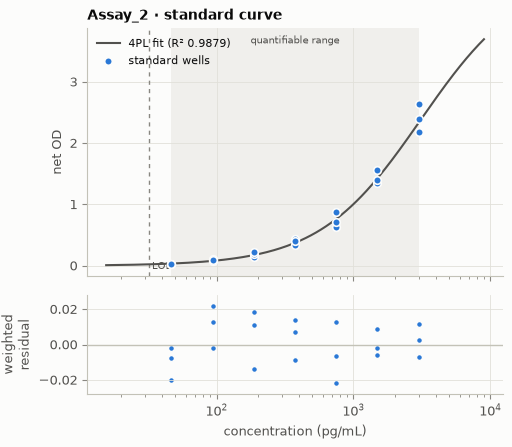

In [3]:
k = ("Assay_2_p1", "analyte (undisclosed)")
w = result.wells[result.wells.plate_id == k[0]]
show(
    P.plot_standard_curve(
        result.fits[k],
        w,
        result.limits.set_index(["plate_id", "analyte"]).loc[k],
        title="Assay_2 · standard curve",
        units="pg/mL",
    )
)

## 2 · Rule-based outlier QC vs the analyst's masks

These plates run in **triplicate**, so the replicate test is live. The modified z-score is
applied only to groups whose raw-OD CV already exceeds 20%. Without that gate, the MAD of three
values is simply the smaller of two deviations. The ungated rule flagged 23 wells here, only 6
of which the analyst had masked. That was the motivation for the gate.

In [4]:
w = result.wells.copy()
w["analyst_masked"] = w["operator_masked"].astype(str).eq("True")
display(
    pd.crosstab(
        w.analyst_masked, w.outlier, rownames=["analyst masked"], colnames=["pipeline outlier"]
    )
)


def group_cv(row):
    g = w[
        (w.plate_id == row.plate_id)
        & (w.type == row.type)
        & (w.sample_id == row.sample_id)
        & (w.dilution == row.dilution)
    ]
    return 100 * g.od.std(ddof=1) / g.od.mean()


masked = w[w.analyst_masked | w.outlier].copy()
masked["replicate_group_cv_pct"] = masked.apply(group_cv, axis=1)
masked[
    [
        "plate_id",
        "well",
        "type",
        "sample_id",
        "od",
        "analyst_masked",
        "outlier",
        "replicate_group_cv_pct",
    ]
].sort_values("replicate_group_cv_pct", ascending=False)

pipeline outlier,False,True
analyst masked,,
False,340,0
True,13,4


,plate_id,well,type,sample_id,od,analyst_masked,outlier,replicate_group_cv_pct
104,Assay_3_and_4_p1,D8,sample,Assay_3_and_4_p1:P7,0.180,True,True,37.159
285,Assay_11_and_12_p1,H1,blank,BLANK,0.051,True,True,30.240
28,Assay_2_p1,D4,sample,Assay_2_p1:P5,0.057,True,True,25.235
354,Assay_11_and_12_p2,H1,blank,BLANK,0.049,True,True,21.009
14,Assay_2_p1,C1,standard,STD3,0.653,True,False,16.516
36,Assay_2_p1,E1,standard,STD5,0.178,True,False,16.227
133,Assay_3_and_4_p1,G4,sample,Assay_3_and_4_p1:P6,0.090,True,False,15.341
33,Assay_2_p1,D9,sample,Assay_2_p1:P7,0.082,True,False,14.006
47,Assay_2_p1,F1,standard,STD6,0.105,True,False,12.685
251,Assay_11_and_12_p1,D11,sample,Assay_11_and_12_p1:P14,0.110,True,False,11.900


**Every well the pipeline removed was also removed by the analyst** (4 of 4). The analyst
removed 13 more, and **all 13** came from replicate groups whose CV was already within 20%. One
(Assay_11_and_12, A3) came from a triplicate with a CV of **1.8%**.
Masking a well in a group that already meets the precision criterion changes the mean very
little. What it does is make the reported CV look better than the measurement was. That kind of
undocumented, discretionary exclusion is what bioanalytical guidance asks labs to replace with a
**pre-specified rule**, and it is what the pipeline enforces.

## 3 · Kit-lot batch effect and bridge normalization

The QC control is the same material on every plate, so it serves as a bridge. If calibration
were perfect, its measured concentration would be identical on all five plates.

In [5]:
ctrl = result.results[result.results.type == "control"].merge(
    manifest[["plate_id", "batch"]], on="plate_id"
)
f = result.plate_factors.merge(manifest[["plate_id", "batch"]], on="plate_id")
display(
    ctrl[["plate_id", "batch", "conc", "conc_norm"]].rename(
        columns={"conc": "QC control (raw)", "conc_norm": "after normalization"}
    )
)
display(f[["plate_id", "batch", "factor"]])
lot = f.groupby("batch")["factor"].apply(lambda x: np.exp(np.log(x).mean()))
print(
    f"Batch 2 reads {100 * (lot['Batch2'] / lot['Batch1'] - 1):+.0f}% relative to Batch 1 "
    f"(geometric mean of plate factors); inter-plate CV of the control: "
    f"{result.bridge_cv.inter_plate_cv_pct_before.iloc[0]:.1f}% raw"
)

,plate_id,batch,QC control (raw),after normalization
0,Assay_2_p1,Batch1,868.471,653.109
1,Assay_3_and_4_p1,Batch1,693.536,653.109
2,Assay_3_and_4_p2,Batch1,714.587,653.109
3,Assay_11_and_12_p1,Batch2,478.142,653.109
4,Assay_11_and_12_p2,Batch2,577.422,653.109


,plate_id,batch,factor
0,Assay_2_p1,Batch1,1.330
1,Assay_3_and_4_p1,Batch1,1.062
2,Assay_3_and_4_p2,Batch1,1.094
3,Assay_11_and_12_p1,Batch2,0.732
4,Assay_11_and_12_p2,Batch2,0.884


Batch 2 reads -30% relative to Batch 1 (geometric mean of plate factors); inter-plate CV of the control: 22.2% raw


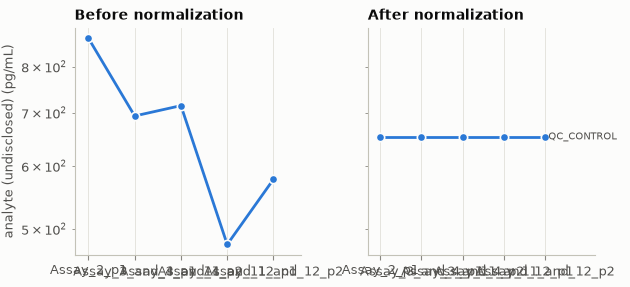

In [6]:
show(P.plot_normalization(result.results, "analyte (undisclosed)", units="pg/mL"))

**Interpretation.**

* The control's between-plate CV is 22% before correction, comparable to the whole ±20–25%
  acceptance window for a single measurement. The plate factors cluster by lot: the **Batch 2
  plates read about 30% lower** than Batch 1. This is exactly the long-term lot-to-lot drift
  the ELISAtools authors set out to correct. A study that switched kit lots midway would have
  shown a spurious shift in patient values at the switch.
* **Caveat, and it matters.** With a *single* bridge sample, normalization forces the control to
  be identical on every plate. The "after" CV is 0% by construction and cannot validate the
  correction. The factor also absorbs that control's own measurement noise (8–10%
  within-plate CV on these plates). In a real study, use **several bridge levels**, as in the simulated demo: the
  pipeline then fits a two-way log-scale model, reports a standard error per plate factor, and
  the post-correction CV of each bridge becomes an honest check.
* The unknowns P1–P15 are *not* the same patients from plate to plate (the labels are template
  slots), so they cannot be used to check the correction either. `scripts/prepare_elisatools.py`
  therefore prefixes them with the plate ID.